冷等离子体色散关系

使用$f_{\rm ce}$归一化

测试程序

In [2]:
using JSON
file = open("data_format.json", "r")
data = JSON.parse(read(file, String))
close(file)
root_path = data["save_path"] #所有文件的根目录
data_model = data["data_model"]

Dict{String, Any} with 13 entries:
  "KP"           => Any["kp/insitu/", "^mvn_kp_insitu_.+\\.tab\$", "KP/", "read…
  "SWEA_spec"    => Any["swe/l2/", "mvn_swe_l2_svyspec_.+\\.cdf", "SWEA/svyspec…
  "STATIC"       => Any["sta/l2/", "mvn_sta_l2_c6-32e64m_.+\\.cdf", "STATIC/c6-…
  "LPW_wn"       => Any["lpw/l2/", "mvn_lpw_l2_wn_.+\\.cdf", "LPW/wn/", "load_l…
  "MAG_ss"       => Any["mag/l2/", "mvn_mag_l2_\\d{7}ss_\\d{8}_v\\d{2}_r\\d{2}\…
  "LPW_wave"     => Any["lpw/l2/", "mvn_lpw_l2_wspecpas_.+\\.cdf", "LPW/wspecpa…
  "MAG_ss1s"     => Any["mag/l2/", "mvn_mag_l2_\\d{7}ss1s_\\d{8}_v\\d{2}_r\\d{2…
  "MAG_pc"       => Any["mag/l2/", "mvn_mag_l2_\\d{7}pc_\\d{8}_v\\d{2}_r\\d{2}\…
  "SWEA_pad_arc" => Any["swe/l2/", "mvn_swe_l2_arcpad_.+\\.cdf", "SWEA/arcpad/"…
  "LPW_lpnt"     => Any["lpw/l2/", "mvn_lpw_l2_lpnt_.+\\.cdf", "LPW/lpnt/", "lo…
  "LPW_mrgscpot" => Any["lpw/l2/", "mvn_lpw_l2_mrgscpot_.+\\.cdf", "LPW/mrgscpo…
  "SWEA_pad_svy" => Any["swe/l2/", "mvn_swe_l2_svypad_.+\\.cdf", "SWEA/svy

In [4]:
using ColorTypes, CairoMakie

In [1]:
const me=9.10938215e-31  
const mp=1.672621637e-27
const RAD=1.0 / 180 * π
const eV=1.602176487e-19

global Nparticles
global Ω_n
global Π_2

function set_particles(ion_rate=[],ion_mass=[])
  ion_rate = [0.4,0.6]
  ion_mass = [16,32]
  particles= 1.0 ./ [1.0,ion_mass...]
  particles_rate = [1.0,ion_rate...]
  global Nparticles=length(particles)
  # 以电子回旋频率归一化  fce 为负值
  global Ω_n = fill(me/mp,Nparticles) ; Ω_n[1] = -1.0 ; Ω_n = Ω_n .* particles
  global Π_2 = fill(me/mp,Nparticles) ; Π_2[1] = 1.0 ; Π_2 = Π_2  .* particles_rate .* particles
end

function Dispersion_Relation(θ,freq,Πe,Ωe,polar=:right)

  Πe_n = Πe / (-Ωe)
  freq_n = freq ./ (-Ωe) 
  Π_2_local = Π_2 * Πe_n^2 
  
  Nf = length(freq_n)
  wave_vector=zeros(Nf)

  for j = 1:Nf
    #计算介电常数
    R=1.0
    L=1.0
    P=1.0
    for i=1:Nparticles
      R=R-Π_2_local[i]/freq_n[j]^2*( freq_n[j] / (freq_n[j]+Ω_n[i]) )
      L=L-Π_2_local[i]/freq_n[j]^2*( freq_n[j] / (freq_n[j]-Ω_n[i]) )
      P=P-Π_2_local[i]/freq_n[j]^2
    end
    
    S=(R+L)/2.
    A=S*sin(θ)^2+P*cos(θ)^2
    B=R*L*sin(θ)^2+P*S*(1+cos(θ)^2)
    C=P*R*L
    D=(R-L)/2.
    #计算折光率μ  (μ^2=real)
    F=sqrt(abs(B^2 - A*C*4.))
    μ=[B+F,B-F]/2.0/A
    index_polar=sortperm( (μ .- S ) ./D )
    μ=μ[index_polar][2]
    μ=real(sqrt(complex(μ,0)))
    wave_vector[j]=μ* freq[j] / 3e8
  end
  return wave_vector
  end
function minimum_energy(θ,freq,Ωe,wave_vector,n)
    v_para = (freq-n*Ωe)/wave_vector/cos(θ)
    Emin   = 0.5 * me * v_para^2 / eV
    return Emin
end
function carculate(θ,freq,Πe,Ωe,n)
    NΠ=length(Πe)
    Nf=length(freq)
    Emin=zeros(Nf,NΠ)
    for j=1:NΠ
        wave_vector= Dispersion_Relation(θ,freq,Πe[j],Ωe)
        Emin[:,j] = minimum_energy.(θ,freq,Ωe,wave_vector,n)
    end
    return Emin
end

carculate (generic function with 1 method)

In [2]:
freq = 10:1:1000 ; freq = freq *2*π
Ωe = -2000 * 2 *π
Πe = 50:250;   Πe = Πe * (-Ωe)
θ = 30.0 * RAD
set_particles()
n=-1
Emin=carculate(θ,freq,Πe,Ωe,n);

In [13]:
[-1.0; fill(2, 3)]

4-element Vector{Float64}:
 -1.0
  2.0
  2.0
  2.0

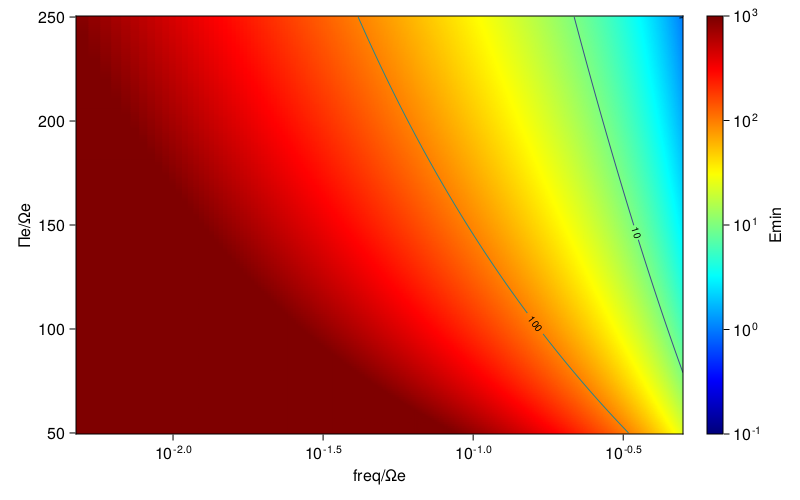

In [7]:
# 绘制数据为等值线图
x = freq / (-Ωe)
y = Πe / (-Ωe)
c = Emin
fig= Figure(resolution = (800,500))
ax = Axis(fig[1,1], xlabel = "freq/Ωe", ylabel = "Πe/Ωe",xscale=log10 )
hm_pad1=heatmap!(ax,x,y,c,colorscale=log10,colorrange=(1e-1,1e3),colormap=:jet)
Colorbar(fig[1,2],hm_pad1,label="Emin")
contour!(ax,x,y,c,colorscale=log10,overdraw=:true,labelcolor=:black, levels=[1e-3,1e-2,1e-1,1e0,1e1,1e2],labels=true)
fig
